# CNN - Оценка на модела (Evaluation)
Този ноутбук зарежда обучения модел и го оценява върху тестовия набор от данни.

In [1]:
import os
import sys
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.models.CNN_model import DeepAudioCNN
from src.data_processing.audio_dataset import AudioFolderDataset

In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Използвано устройство: {DEVICE}")

TEST_CSV = "../data/test_split.csv"
AUDIO_DIR = "../data/Dataset_Final"
MODEL_WEIGHTS = "../models/best_deepcnn.pth"
BATCH_SIZE = 32

Използвано устройство: cpu


In [3]:
print("Зареждане на тестовите данни...")
# Използвай новия параметър csv_file
test_dataset = AudioFolderDataset(root_dir="../data/Dataset_Final", csv_file=TEST_CSV, augment=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f"Брой тестови записи: {len(test_dataset)}")


Зареждане на тестовите данни...
Зареждане на данни от сплит файл: ../data/test_split.csv
Брой тестови записи: 443


In [4]:
print("Инициализация на модела...")
model = DeepAudioCNN(n_classes=8).to(DEVICE)

print("Зареждане на запазените тегла...")
if os.path.exists(MODEL_WEIGHTS):
    model.load_state_dict(torch.load(MODEL_WEIGHTS, map_location=DEVICE))
    model.eval()
    print("Моделът е зареден успешно!")
else:
    print(f"ГРЕШКА: Файлът с теглата не е намерен на път {MODEL_WEIGHTS}")

Инициализация на модела...
Зареждане на запазените тегла...
Моделът е зареден успешно!


In [5]:
all_preds = []
all_labels = []

print("Стартиране на инференцията...")
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Testing"):
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)
        
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Оценката приключи!")

test_acc = accuracy_score(all_labels, all_preds)
print(f"Тестова точност (Test Accuracy): {test_acc:.4f} ({test_acc*100:.2f}%)")

Стартиране на инференцията...


Testing:   0%|          | 0/14 [00:00<?, ?it/s]

Оценката приключи!
Тестова точност (Test Accuracy): 0.8307 (83.07%)


In [6]:
class_names = [
    "Baby_Cry", "Background", "Car_Horn", "Construction", 
    "Dog_Bark", "Door_Signal", "Glass_Break", "Siren_Alarm"
]


print("--- Доклад от класификацията (Classification Report) ---")
print(classification_report(all_labels, all_preds, target_names=class_names))

--- Доклад от класификацията (Classification Report) ---
              precision    recall  f1-score   support

    Baby_Cry       1.00      0.57      0.73        40
  Background       0.92      0.93      0.92        70
    Car_Horn       0.93      1.00      0.97        43
Construction       0.85      0.97      0.91        70
    Dog_Bark       0.57      0.93      0.71        70
 Door_Signal       0.91      0.80      0.85        40
 Glass_Break       1.00      0.07      0.14        40
 Siren_Alarm       0.97      0.99      0.98        70

    accuracy                           0.83       443
   macro avg       0.89      0.78      0.78       443
weighted avg       0.88      0.83      0.80       443



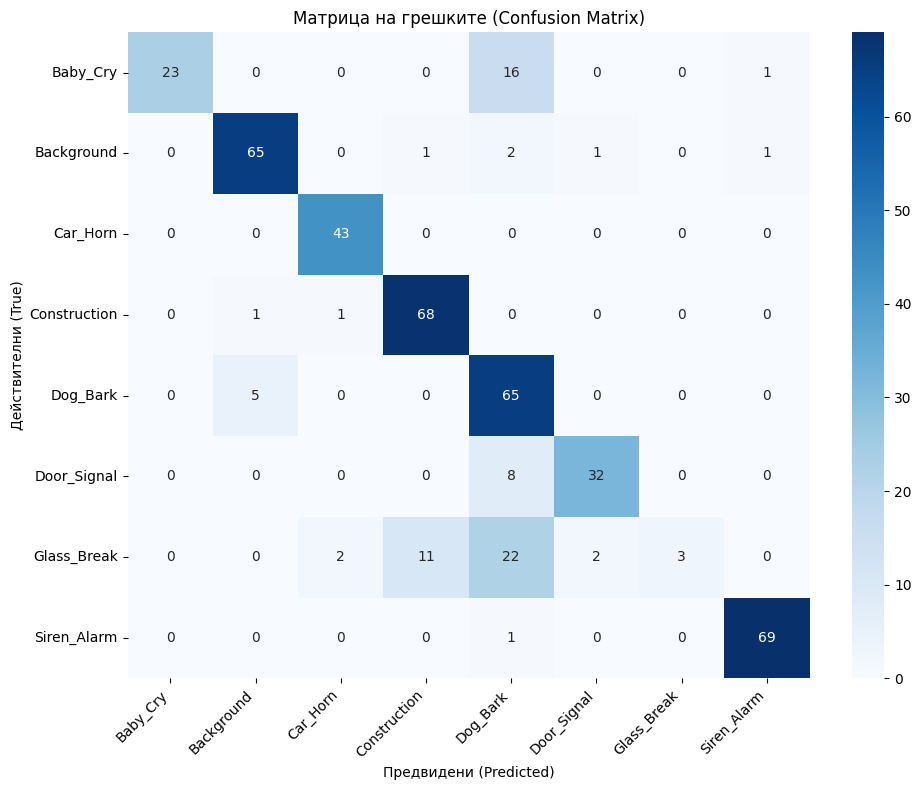

In [7]:
plt.figure(figsize=(10, 8))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Предвидени (Predicted)')
plt.ylabel('Действителни (True)')
plt.title('Матрица на грешките (Confusion Matrix)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Анализ на резултатите: DeepAudioCNN Sound Classification
1. Общ преглед на производителността
Моделът DeepAudioCNN постига много добра обща точност (Accuracy) от 83% върху тестовия набор от данни. Архитектурата демонстрира висока надеждност при разпознаването на продължителни и отчетливи звуци, но все още среща затруднения с кратките, импулсни събития.

Ключови метрики:

Precision (Macro Avg): 0.89

Recall (Macro Avg): 0.78

F1-Score (Weighted Avg): 0.80

2. Детайлен анализ по класове
✅ Отлично представяне (Над 90% точност)

🚨 Siren_Alarm: Почти перфектен резултат с 0.99 Recall и 0.97 Precision. Само 1 от 70 записа е пропуснат (класифициран като Dog_Bark).

🚗 Car_Horn: Отличен резултат с 1.00 Recall, което означава, че моделът не е пропуснал нито един клаксон в теста.

🛠️ Construction: Много висока ефективност (0.97 Recall), като 68 от 70 строителни шума са уловени правилно.

🤫 Background: Моделът филтрира околния шум изключително успешно с 0.92 Precision, предотвратявайки фалшиви аларми.

⚠️ Предизвикателства и обърквания

🐕 Dog_Bark (Precision 0.57): Въпреки високия Recall (0.93), прецизността е ниска. Това означава, че моделът има тенденция да "чува" кучешки лай в много други звуци – 22 записа на Glass_Break и 16 на Baby_Cry са погрешно класифицирани като куче.

👶 Baby_Cry (Recall 0.57): Значително подобрение спрямо базовия CNN, но все още 40% от бебешкия плач се губи, като основната част отива към Dog_Bark.

🔔 Door_Signal (F1-score 0.85): Солидно представяне, като 32 от 40 случая на чукане/звънец са разпознати правилно.

3. Критична слабост: Glass_Break
Glass_Break (0.07 Recall): Това остава най-слабият пункт на модела. Само 3 от 40 записа на чупещо се стъкло са идентифицирани.

Анализ на грешката: Огромното мнозинство от тези записи (22 броя) се бъркат с кучешки лай, а 11 броя – със строителни дейности. Това показва, че моделът не успява да изолира специфичните "кристални" честоти на стъклото от общия шум.